#  Customer Segmentation using K-Means Clustering
  
**Topic:** Clustering (Unsupervised Learning)  
**Algorithm:** K-Means Clustering  




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [4]:
# Read the uploaded Excel file
# The data points (A1-A8) are located at rows 13-20 in the sheet (0-indexed row 12-19)
# Columns: index (col 0), x1 (col 1), x2 (col 2)

raw = pd.read_excel('Clustering_Class.xlsx', header=None)

# Extract the 8 customer data points from the known rows
data_rows = raw.iloc[13:21, [0, 1, 2]].copy()
data_rows.columns = ['CustomerID', 'x1', 'x2']
data_rows = data_rows.reset_index(drop=True)

# Ensure numeric types
data_rows['x1'] = pd.to_numeric(data_rows['x1'])
data_rows['x2'] = pd.to_numeric(data_rows['x2'])

df = data_rows.copy()

print(' Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} customers × {df.shape[1]} columns\n')
print(df.to_string(index=False))

 Dataset loaded successfully!
   Shape: 8 customers × 3 columns

CustomerID  x1  x2
        A1   2  10
        A2   2   5
        A3   8   4
        A4   5   8
        A5   7   5
        A6   6   4
        A7   1   2
        A8   4   9



##  Exploratory Data Analysis (EDA)

In [5]:
print('=' * 45)
print('         DATASET OVERVIEW')
print('=' * 45)
print(f'\nNumber of customers : {len(df)}')
print(f'Features            : x1, x2')
print(f'Missing values      : {df.isnull().sum().sum()}')

print('\n--- Descriptive Statistics ---')
print(df[['x1', 'x2']].describe().round(2))

         DATASET OVERVIEW

Number of customers : 8
Features            : x1, x2
Missing values      : 0

--- Descriptive Statistics ---
         x1     x2
count  8.00   8.00
mean   4.38   5.88
std    2.56   2.80
min    1.00   2.00
25%    2.00   4.00
50%    4.50   5.00
75%    6.25   8.25
max    8.00  10.00


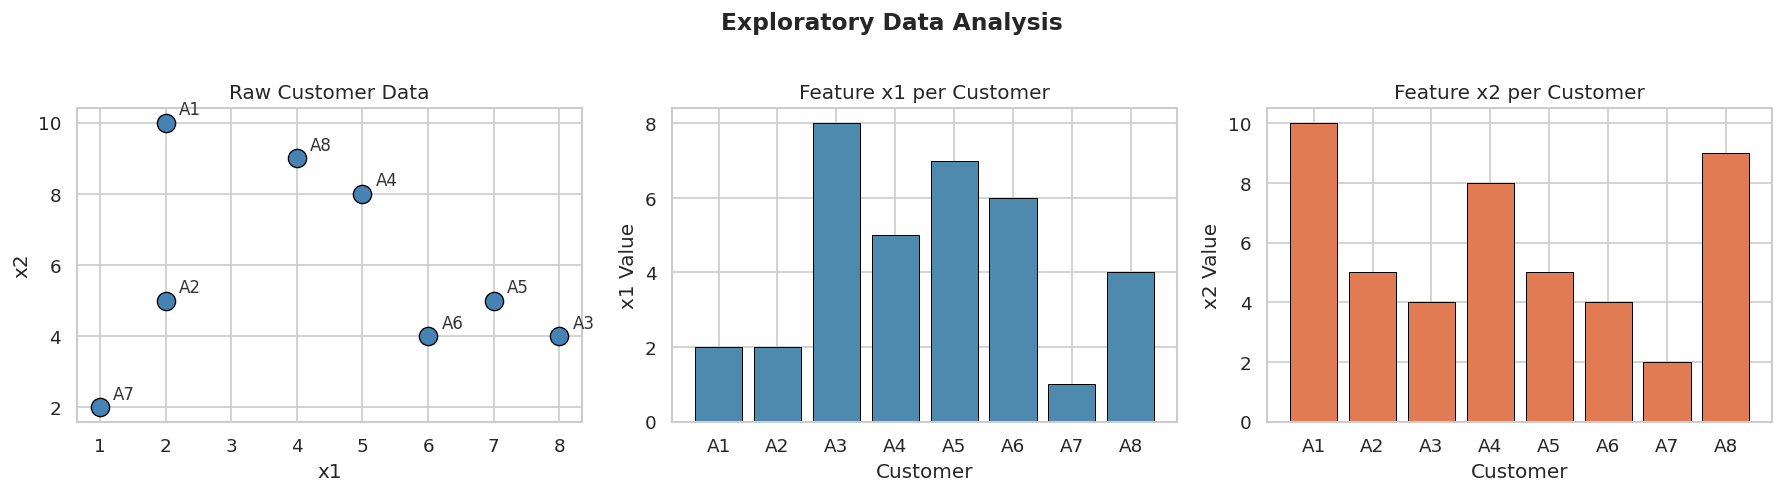

In [6]:
# Visualize raw data distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter plot of raw data
axes[0].scatter(df['x1'], df['x2'], s=120, color='steelblue', edgecolors='black', linewidths=0.8)
for _, row in df.iterrows():
    axes[0].annotate(row['CustomerID'], (row['x1'], row['x2']),
                     textcoords='offset points', xytext=(8, 5), fontsize=10, color='#333')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Raw Customer Data')

# x1 distribution
axes[1].bar(df['CustomerID'], df['x1'], color='#4e89ae', edgecolor='black', linewidth=0.6)
axes[1].set_xlabel('Customer')
axes[1].set_ylabel('x1 Value')
axes[1].set_title('Feature x1 per Customer')

# x2 distribution
axes[2].bar(df['CustomerID'], df['x2'], color='#e07b54', edgecolor='black', linewidth=0.6)
axes[2].set_xlabel('Customer')
axes[2].set_ylabel('x2 Value')
axes[2].set_title('Feature x2 per Customer')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


##  Data Preprocessing — Feature Scaling



In [7]:
X = df[['x1', 'x2']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature Scaling applied (StandardScaler)\n')
print(f'{"Customer":<12} {"x1 (orig)":<12} {"x2 (orig)":<12} {"x1 (scaled)":<14} {"x2 (scaled)":<14}')
print('-' * 65)
for i, row in df.iterrows():
    print(f"{row['CustomerID']:<12} {row['x1']:<12} {row['x2']:<12} "
          f"{X_scaled[i][0]:<14.4f} {X_scaled[i][1]:<14.4f}")

print(f'\nScaled x1 — Mean: {X_scaled[:,0].mean():.6f}, Std: {X_scaled[:,0].std():.4f}')
print(f'Scaled x2 — Mean: {X_scaled[:,1].mean():.6f}, Std: {X_scaled[:,1].std():.4f}')

Feature Scaling applied (StandardScaler)

Customer     x1 (orig)    x2 (orig)    x1 (scaled)    x2 (scaled)   
-----------------------------------------------------------------
A1           2            10           -0.9918        1.5750        
A2           2            5            -0.9918        -0.3341       
A3           8            4            1.5138         -0.7159       
A4           5            8            0.2610         0.8114        
A5           7            5            1.0962         -0.3341       
A6           6            4            0.6786         -0.7159       
A7           1            2            -1.4094        -1.4795       
A8           4            9            -0.1566        1.1932        

Scaled x1 — Mean: 0.000000, Std: 1.0000
Scaled x2 — Mean: 0.000000, Std: 1.0000



##  Finding Optimal K — Elbow Method + Silhouette Analysis

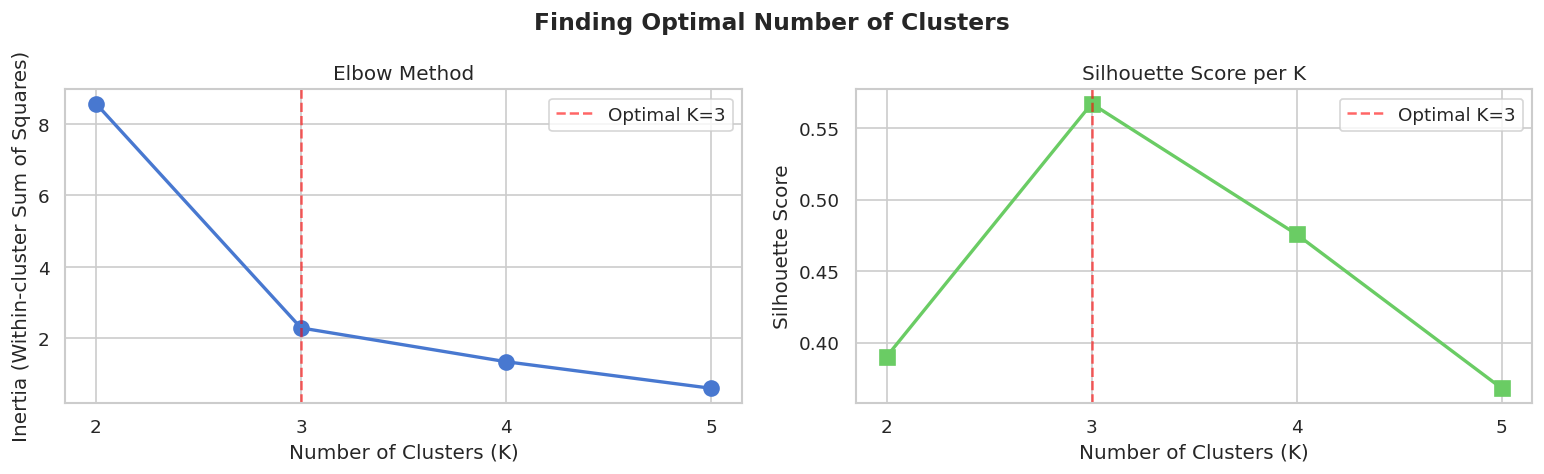


K | Inertia  | Silhouette Score
------------------------------------
2 |    8.569 | 0.3903
3 |    2.295 | 0.5670 ← Best
4 |    1.349 | 0.4757
5 |    0.606 | 0.3682


In [8]:
inertia_values    = []
silhouette_values = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, km.labels_))

# Plot both methods side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=9)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Optimal K=3')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(k_range, silhouette_values, 'gs-', linewidth=2, markersize=9)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Optimal K=3')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.suptitle('Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nK | Inertia  | Silhouette Score')
print('-' * 36)
for k, iner, sil in zip(k_range, inertia_values, silhouette_values):
    marker = ' ← Best' if k == 3 else ''
    print(f'{k} | {iner:8.3f} | {sil:.4f}{marker}')


##  Apply K-Means Clustering (K = 3)

In [9]:
# Applying K-Means with K=3 (matches class dataset with 3 centroids: C1, C2, C3)
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_
df['Cluster_Label'] = df['Cluster'].map({0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C'})

# Centroids in original scale
centroids_scaled   = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

print('K-Means Clustering Results (K=3)')
print('=' * 50)
print(df[['CustomerID', 'x1', 'x2', 'Cluster_Label']].to_string(index=False))

print('\n--- Final Centroids (Original Scale) ---')
print(f'{"Centroid":<12} {"x1":<10} {"x2":<10}')
print('-' * 32)
for i, c in enumerate(centroids_original):
    print(f'Cluster {chr(65+i):<5} {c[0]:<10.3f} {c[1]:<10.3f}')

print(f'\nIterations to converge: {kmeans.n_iter_}')

K-Means Clustering Results (K=3)
CustomerID  x1  x2 Cluster_Label
        A1   2  10     Cluster B
        A2   2   5     Cluster C
        A3   8   4     Cluster A
        A4   5   8     Cluster B
        A5   7   5     Cluster A
        A6   6   4     Cluster A
        A7   1   2     Cluster C
        A8   4   9     Cluster B

--- Final Centroids (Original Scale) ---
Centroid     x1         x2        
--------------------------------
Cluster A     7.000      4.333     
Cluster B     3.667      9.000     
Cluster C     1.500      3.500     

Iterations to converge: 2



##  Visualization

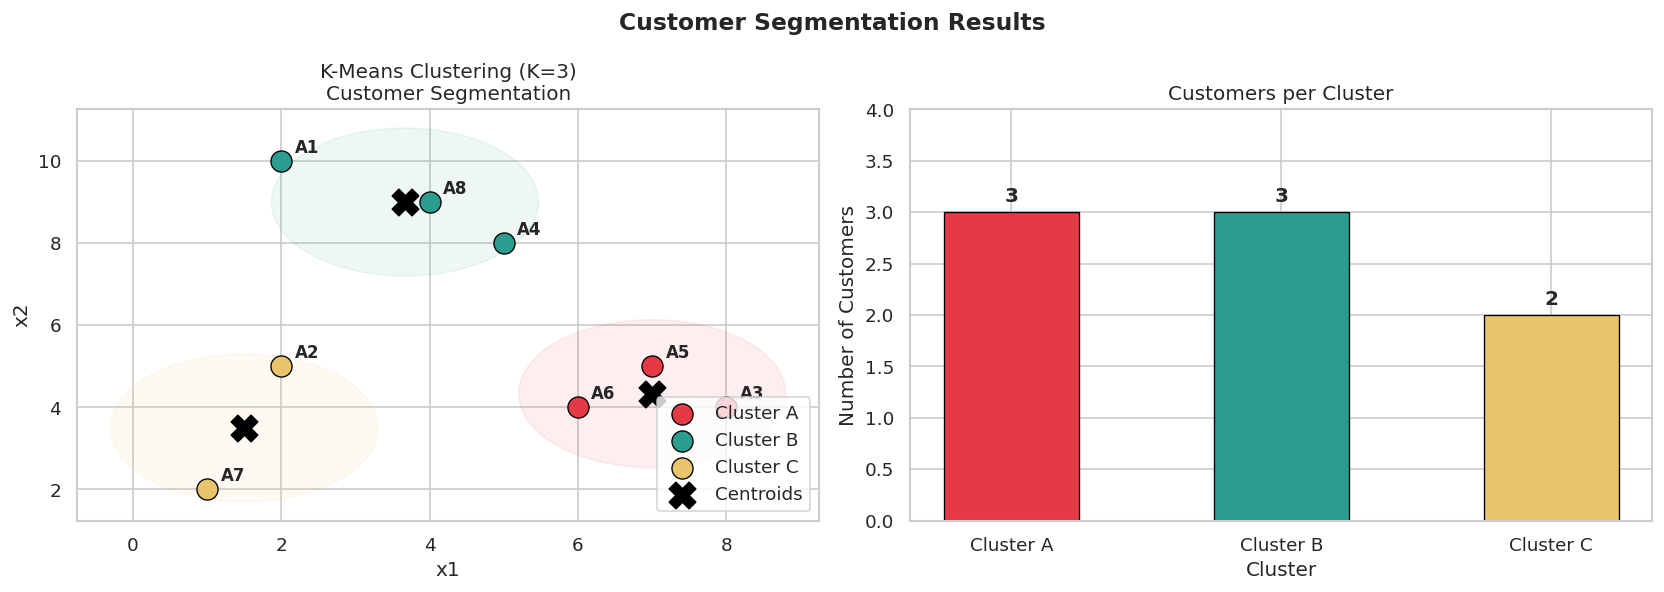

In [10]:
COLORS = ['#E63946', '#2A9D8F', '#E9C46A']
CLUSTER_NAMES = ['Cluster A', 'Cluster B', 'Cluster C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Cluster scatter ---
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[0].scatter(df[mask]['x1'], df[mask]['x2'],
                    color=COLORS[i], label=CLUSTER_NAMES[i],
                    s=160, edgecolors='black', linewidths=0.8, zorder=3)

# Annotate points
for _, row in df.iterrows():
    axes[0].annotate(row['CustomerID'], (row['x1'], row['x2']),
                     textcoords='offset points', xytext=(8, 5),
                     fontsize=10, fontweight='bold')

# Plot centroids
axes[0].scatter(centroids_original[:, 0], centroids_original[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')

# Draw boundary circles around centroids
for i, c in enumerate(centroids_original):
    circle = plt.Circle((c[0], c[1]), 1.8, color=COLORS[i], fill=True, alpha=0.08, zorder=1)
    axes[0].add_patch(circle)

axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('K-Means Clustering (K=3)\nCustomer Segmentation')
axes[0].legend(loc='lower right')

# --- Plot 2: Cluster size bar chart ---
cluster_counts = df['Cluster_Label'].value_counts().sort_index()
bars = axes[1].bar(cluster_counts.index, cluster_counts.values,
                   color=COLORS[:len(cluster_counts)],
                   edgecolor='black', linewidth=0.8, width=0.5)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customers per Cluster')
axes[1].set_ylim(0, max(cluster_counts.values) + 1)

for bar, count in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(count), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Customer Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

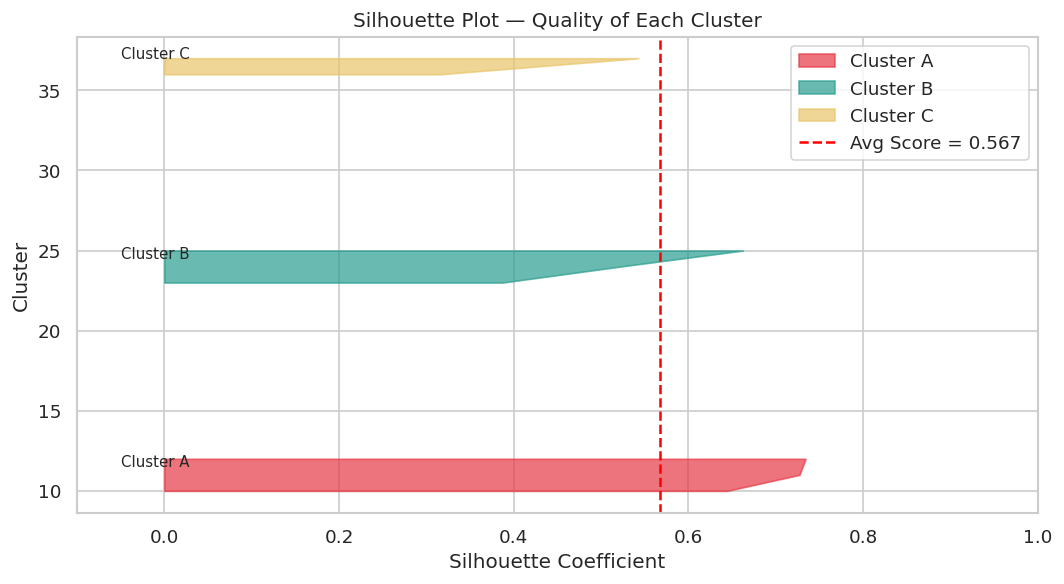

Average Silhouette Score: 0.5670


In [11]:
# Silhouette plot — shows how well each point fits its cluster
fig, ax = plt.subplots(figsize=(9, 5))

sample_silhouette_values = silhouette_samples(X_scaled, kmeans.labels_)
y_lower = 10

for i in range(OPTIMAL_K):
    ith_cluster_silhouette_values = np.sort(sample_silhouette_values[kmeans.labels_ == i])
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     alpha=0.7, color=COLORS[i], label=CLUSTER_NAMES[i])
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, CLUSTER_NAMES[i], fontsize=9)
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, kmeans.labels_)
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg Score = {avg_score:.3f}')

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — Quality of Each Cluster')
ax.set_xlim([-0.1, 1.0])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Average Silhouette Score: {avg_score:.4f}')


##  Hierarchical Clustering (Dendrogram)

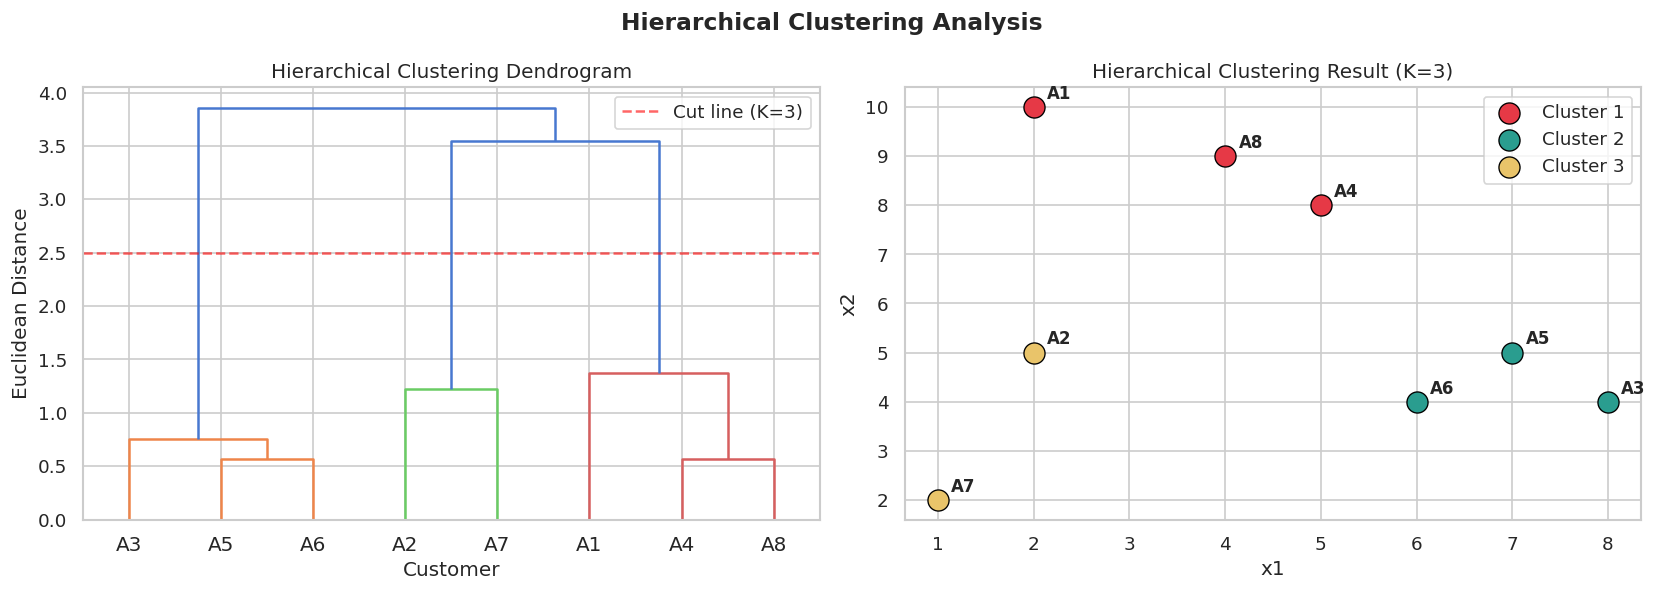

Hierarchical Clustering Silhouette Score: 0.5670


In [12]:
# Hierarchical clustering dendrogram
linked = linkage(X_scaled, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram
dendrogram(
    linked,
    labels=df['CustomerID'].values,
    ax=axes[0],
    color_threshold=2.5,
    leaf_font_size=12
)
axes[0].axhline(y=2.5, color='red', linestyle='--', alpha=0.6, label='Cut line (K=3)')
axes[0].set_title('Hierarchical Clustering Dendrogram')
axes[0].set_xlabel('Customer')
axes[0].set_ylabel('Euclidean Distance')
axes[0].legend()

# Hierarchical cluster scatter
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

for i in range(3):
    mask = hc_labels == i
    axes[1].scatter(df[mask]['x1'], df[mask]['x2'],
                    color=COLORS[i], label=f'Cluster {i+1}',
                    s=160, edgecolors='black', linewidths=0.8)

for _, row in df.iterrows():
    axes[1].annotate(row['CustomerID'], (row['x1'], row['x2']),
                     textcoords='offset points', xytext=(8, 5), fontsize=10, fontweight='bold')

axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_title('Hierarchical Clustering Result (K=3)')
axes[1].legend()

plt.suptitle('Hierarchical Clustering Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

hc_score = silhouette_score(X_scaled, hc_labels)
print(f'Hierarchical Clustering Silhouette Score: {hc_score:.4f}')


##  Model Evaluation & Comparison

In [13]:
# Compare K-Means vs Hierarchical Clustering
km_score  = silhouette_score(X_scaled, kmeans.labels_)
hc_score  = silhouette_score(X_scaled, hc_labels)

print('=' * 55)
print('          MODEL COMPARISON')
print('=' * 55)
print(f'{"Metric":<30} {"K-Means":<12} {"Hierarchical":<12}')
print('-' * 55)
print(f'{"Algorithm":<30} {"K-Means":<12} {"Agglomerative":<12}')
print(f'{"Number of Clusters":<30} {"3":<12} {"3":<12}')
print(f'{"Silhouette Score":<30} {km_score:<12.4f} {hc_score:<12.4f}')
print(f'{"Inertia (K-Means only)":<30} {kmeans.inertia_:<12.3f} {"N/A":<12}')
print(f'{"Iterations to Converge":<30} {kmeans.n_iter_:<12} {"N/A":<12}')
print('=' * 55)

best = 'K-Means' if km_score >= hc_score else 'Hierarchical'
print(f'\n🏆 Best Model: {best} (higher silhouette score = better separation)')

print('\n--- Silhouette Score Interpretation ---')
print('  0.71 – 1.00 : Strong cluster structure')
print('  0.51 – 0.70 : Reasonable cluster structure')
print('  0.26 – 0.50 : Weak cluster structure')
print('  < 0.25      : No substantial cluster structure')

          MODEL COMPARISON
Metric                         K-Means      Hierarchical
-------------------------------------------------------
Algorithm                      K-Means      Agglomerative
Number of Clusters             3            3           
Silhouette Score               0.5670       0.5670      
Inertia (K-Means only)         2.295        N/A         
Iterations to Converge         2            N/A         

🏆 Best Model: K-Means (higher silhouette score = better separation)

--- Silhouette Score Interpretation ---
  0.71 – 1.00 : Strong cluster structure
  0.51 – 0.70 : Reasonable cluster structure
  0.26 – 0.50 : Weak cluster structure
  < 0.25      : No substantial cluster structure



##  Final Summary & Insights

In [18]:
print('     CUSTOMER SEGMENTATION — FINAL SUMMARY')
print(f'\nDataset          : Clustering_Class.xlsx')
print(f'Total Customers  : {len(df)}')
print(f'Features Used    : x1, x2')
print(f'Preprocessing    : StandardScaler (mean=0, std=1)')
print(f'Algorithm        : K-Means Clustering')
print(f'Optimal K        : 3 (Elbow Method + Silhouette)')
print(f'Silhouette Score : {km_score:.4f}')

print('\nCluster Breakdown')
for i in range(OPTIMAL_K):
    members  = df[df['Cluster'] == i]['CustomerID'].tolist()
    centroid = centroids_original[i]
    print(f'\n  {CLUSTER_NAMES[i]}: {members}')
    print(f'    Centroid → x1: {centroid[0]:.2f}, x2: {centroid[1]:.2f}')

print('\n Business Insight ')
for i in range(OPTIMAL_K):
    members  = df[df['Cluster'] == i]
    avg_x1   = members['x1'].mean()
    avg_x2   = members['x2'].mean()
    ids      = ', '.join(members['CustomerID'].tolist())
    print(f'  {CLUSTER_NAMES[i]} ({ids}): avg x1={avg_x1:.1f}, avg x2={avg_x2:.1f}')



     CUSTOMER SEGMENTATION — FINAL SUMMARY

Dataset          : Clustering_Class.xlsx
Total Customers  : 8
Features Used    : x1, x2
Preprocessing    : StandardScaler (mean=0, std=1)
Algorithm        : K-Means Clustering
Optimal K        : 3 (Elbow Method + Silhouette)
Silhouette Score : 0.5670

Cluster Breakdown

  Cluster A: ['A3', 'A5', 'A6']
    Centroid → x1: 7.00, x2: 4.33

  Cluster B: ['A1', 'A4', 'A8']
    Centroid → x1: 3.67, x2: 9.00

  Cluster C: ['A2', 'A7']
    Centroid → x1: 1.50, x2: 3.50

 Business Insight 
  Cluster A (A3, A5, A6): avg x1=7.0, avg x2=4.3
  Cluster B (A1, A4, A8): avg x1=3.7, avg x2=9.0
  Cluster C (A2, A7): avg x1=1.5, avg x2=3.5
